##Dataset Intiallizing

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [110]:
df= pd.read_csv('Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [112]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


In [113]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object

In [114]:
df.isnull().sum()

CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

In [115]:
df['Profession'].value_counts()

Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
Name: count, dtype: int64

In [116]:
df['Profession'].fillna(df['Profession'].mode()[0], inplace=True)

C:\Users\Dison\AppData\Local\Temp\ipykernel_13760\2147842994.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Profession'].fillna(df['Profession'].mode()[0], inplace=True)


In [117]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64

In [118]:
df['Profession'].value_counts()

Profession
Artist           647
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
Name: count, dtype: int64

In [119]:
gender_map={'Male':1,'Female':0}
df['Gender']=df['Gender'].map(gender_map)
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,1,19,15000,39,Healthcare,1,4
1,2,1,21,35000,81,Engineer,3,3
2,3,0,20,86000,6,Engineer,1,1
3,4,0,23,59000,77,Lawyer,0,2
4,5,0,31,38000,40,Entertainment,2,6


In [120]:
under_18_counts = df.loc[df['Age'] < 18, 'Age'].value_counts().sort_index()
print(under_18_counts)

Age
0     24
1     26
2     15
3     18
4     15
5     20
6     14
7     18
8     22
9     13
10    12
11    13
12    20
13    25
14    19
15    20
16    21
17    17
Name: count, dtype: int64


In [ ]:
df = df[df['Age'] >= 18]

## Income Distribution Analysis

<Figure size 1000x600 with 0 Axes>

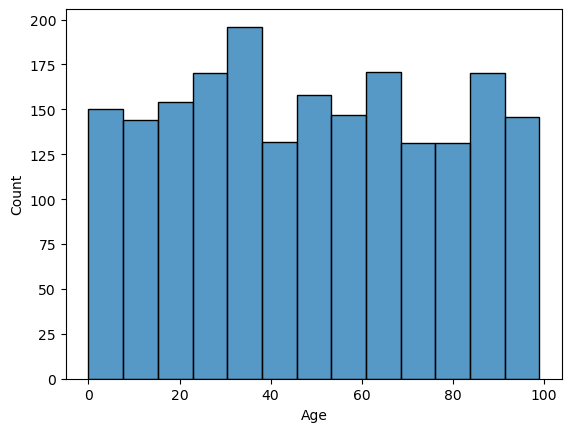

<Figure size 1000x600 with 0 Axes>

In [121]:
sns.histplot(x='Age',data=df)
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

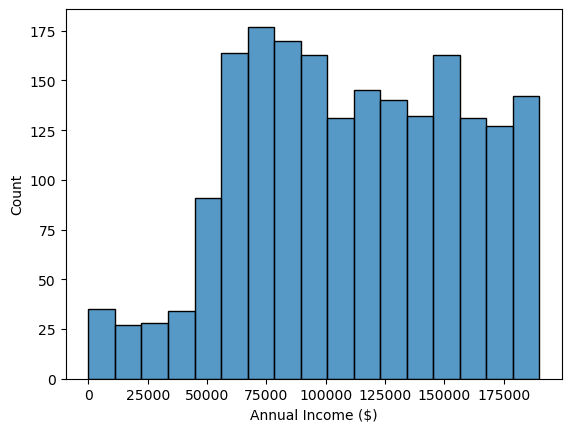

<Figure size 1000x600 with 0 Axes>

In [122]:
sns.histplot(x='Annual Income ($)',data=df)
plt.figure(figsize=(10,6))

Text(0.5, 1.0, 'Average Annual Income by Profession')

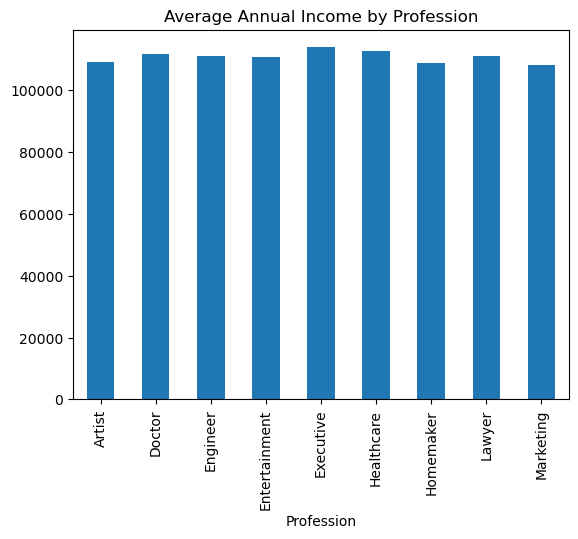

In [123]:
df.groupby('Profession')['Annual Income ($)'].mean().plot(kind='bar')
plt.title('Average Annual Income by Profession')

Text(0.5, 1.0, 'Average Annual Income by Gender')

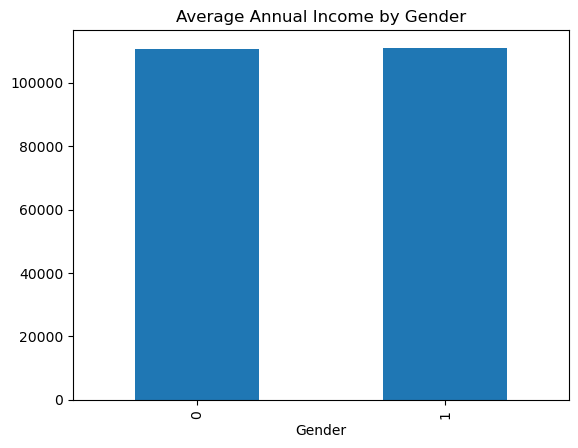

In [124]:
df.groupby('Gender')['Annual Income ($)'].mean().plot(kind='bar')
plt.title('Average Annual Income by Gender')

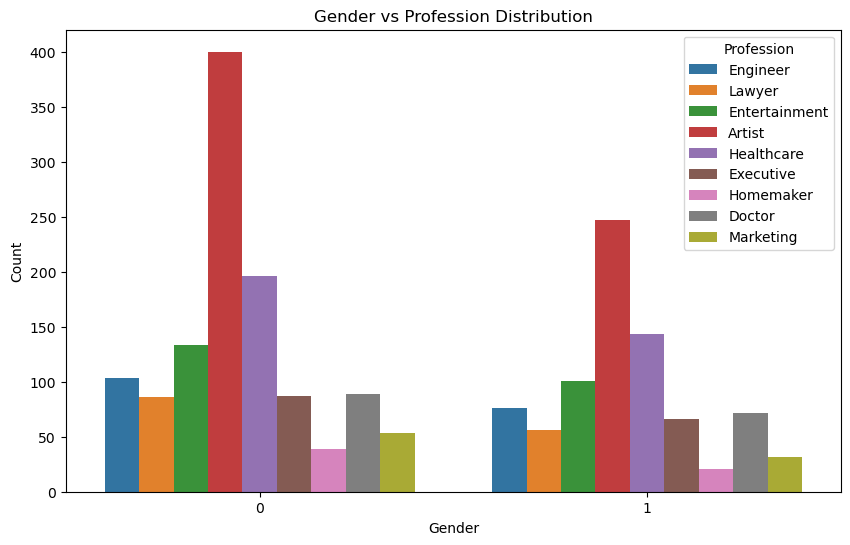

In [125]:
plt.figure(figsize=(10,6))
sns.countplot(x='Gender', hue='Profession', data=df)
plt.title('Gender vs Profession Distribution')
plt.xlabel('Gender')
plt.ylabel('Count') 
plt.legend(title='Profession', loc='upper right')
plt.show()

<Figure size 1000x600 with 0 Axes>

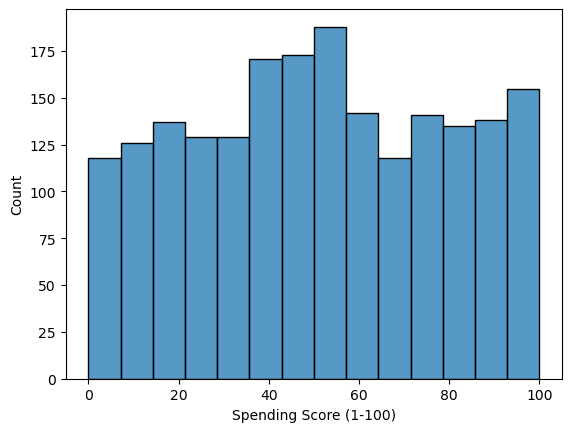

<Figure size 1000x600 with 0 Axes>

In [126]:
sns.histplot(x='Spending Score (1-100)',data=df)
plt.figure(figsize=(10,6))

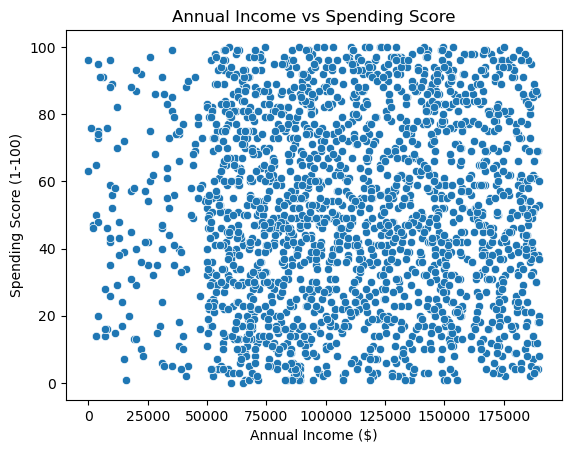

In [127]:
sns.scatterplot(x='Annual Income ($)', y='Spending Score (1-100)', data=df)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.show()

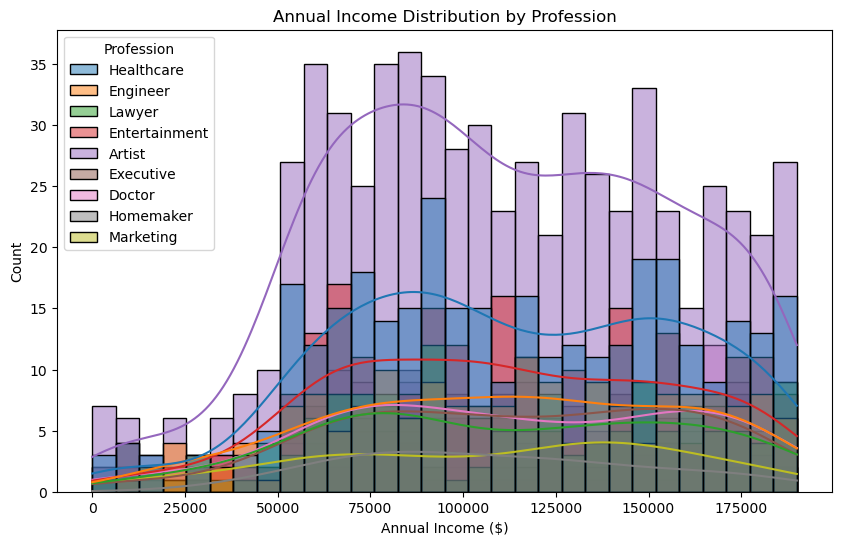

In [128]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x="Annual Income ($)", hue="Profession", bins=30, kde=True)

plt.title("Annual Income Distribution by Profession")
plt.xlabel("Annual Income ($)")
plt.ylabel("Count")
plt.show()

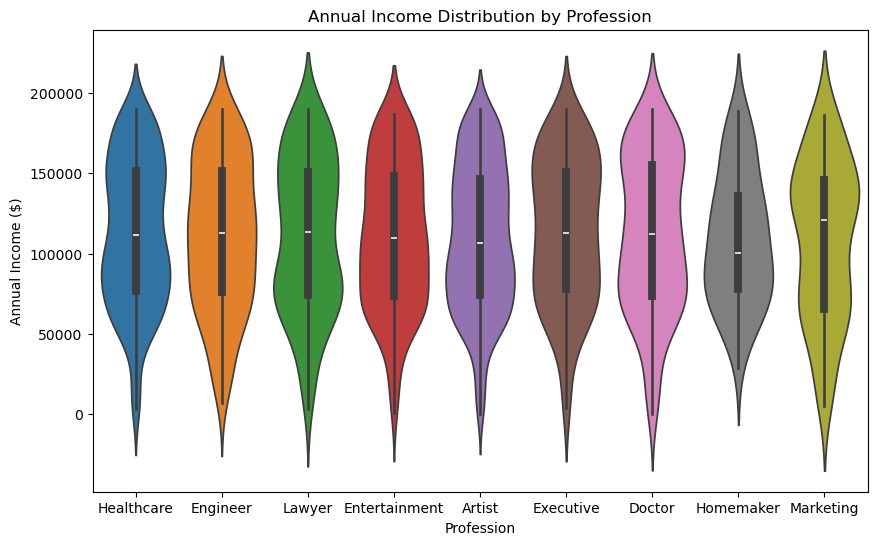

In [129]:
plt.figure(figsize=(10,6))

sns.violinplot(data=df, x="Profession", y="Annual Income ($)",hue="Profession")

plt.title("Annual Income Distribution by Profession")
plt.show()

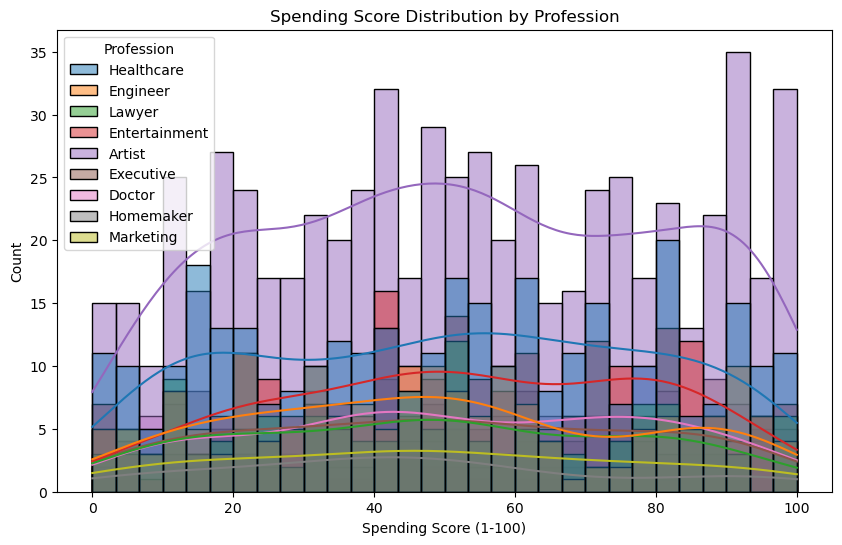

In [130]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x="Spending Score (1-100)", hue="Profession", bins=30, kde=True)

plt.title("Spending Score Distribution by Profession")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Count")
plt.show()

<Figure size 1000x600 with 0 Axes>

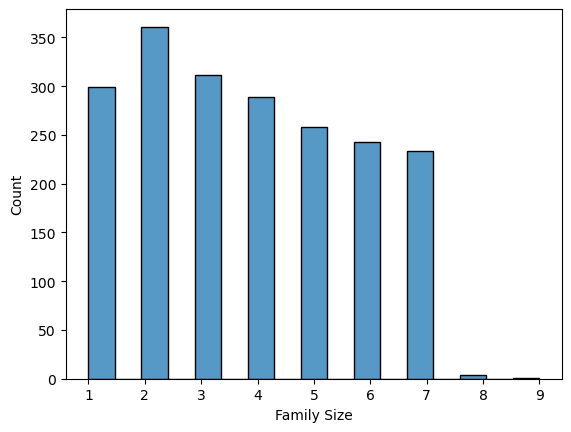

<Figure size 1000x600 with 0 Axes>

In [131]:
sns.histplot(x='Family Size',data=df)
plt.figure(figsize=(10,6))

In [132]:
df['Family Size'].value_counts()

Family Size
2    361
3    311
1    299
4    289
5    258
6    243
7    234
8      4
9      1
Name: count, dtype: int64

In [133]:
df['Family Size'] = df['Family Size'].replace([8,9], df['Family Size'].mode()[0])

In [134]:
df['Family Size'].value_counts()

Family Size
2    366
3    311
1    299
4    289
5    258
6    243
7    234
Name: count, dtype: int64

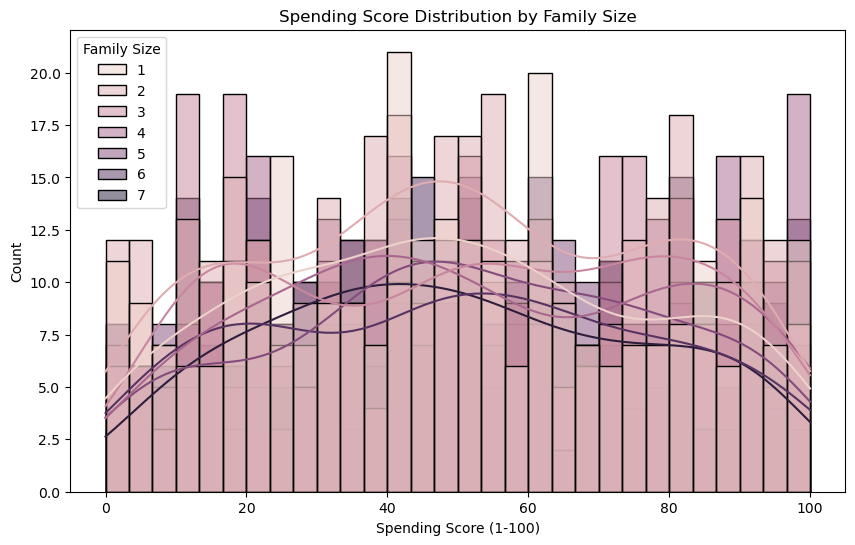

In [135]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x="Spending Score (1-100)", hue="Family Size", bins=30, kde=True)

plt.title("Spending Score Distribution by Family Size")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Count")
plt.show()

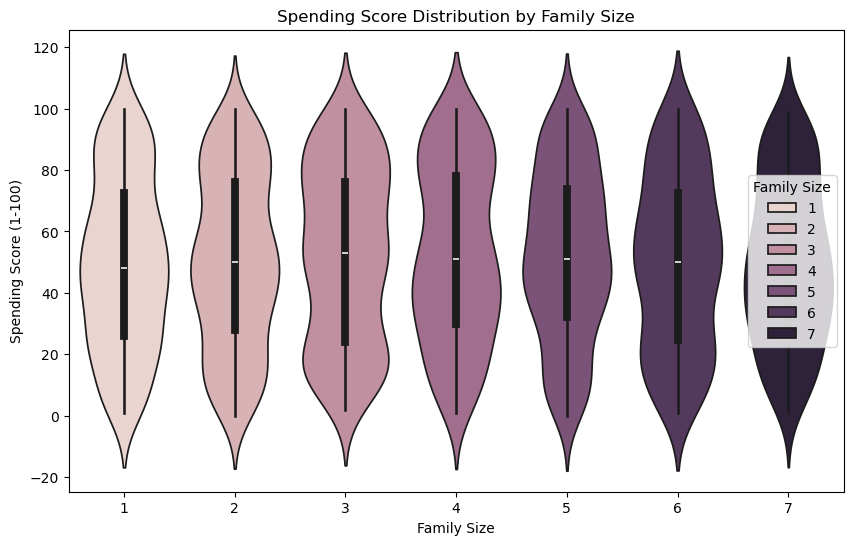

In [136]:
plt.figure(figsize=(10,6))

sns.violinplot(data=df, x="Family Size", y="Spending Score (1-100)",hue="Family Size")

plt.title("Spending Score Distribution by Family Size")
plt.show()

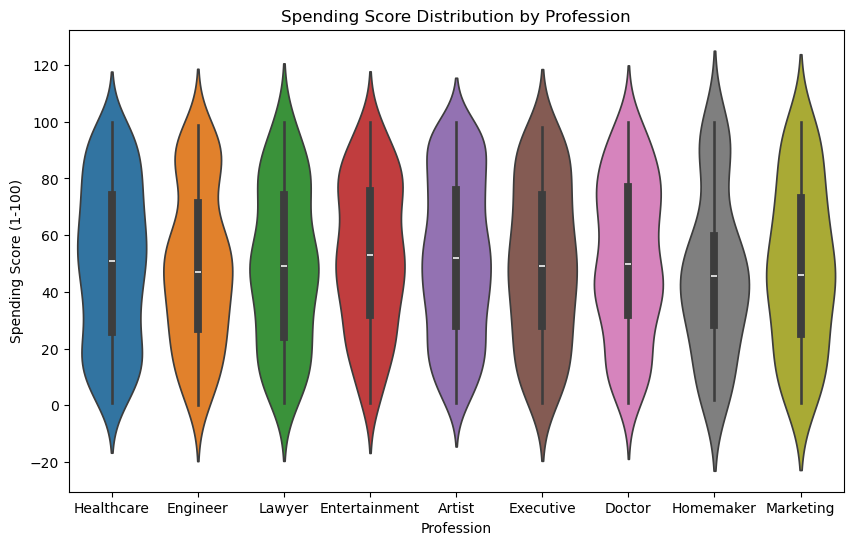

In [137]:
plt.figure(figsize=(10,6))

sns.violinplot(data=df, x="Profession", y="Spending Score (1-100)",hue="Profession")

plt.title("Spending Score Distribution by Profession")
plt.show()

## Outlier Analysis


Text(0, 0.5, 'Count')

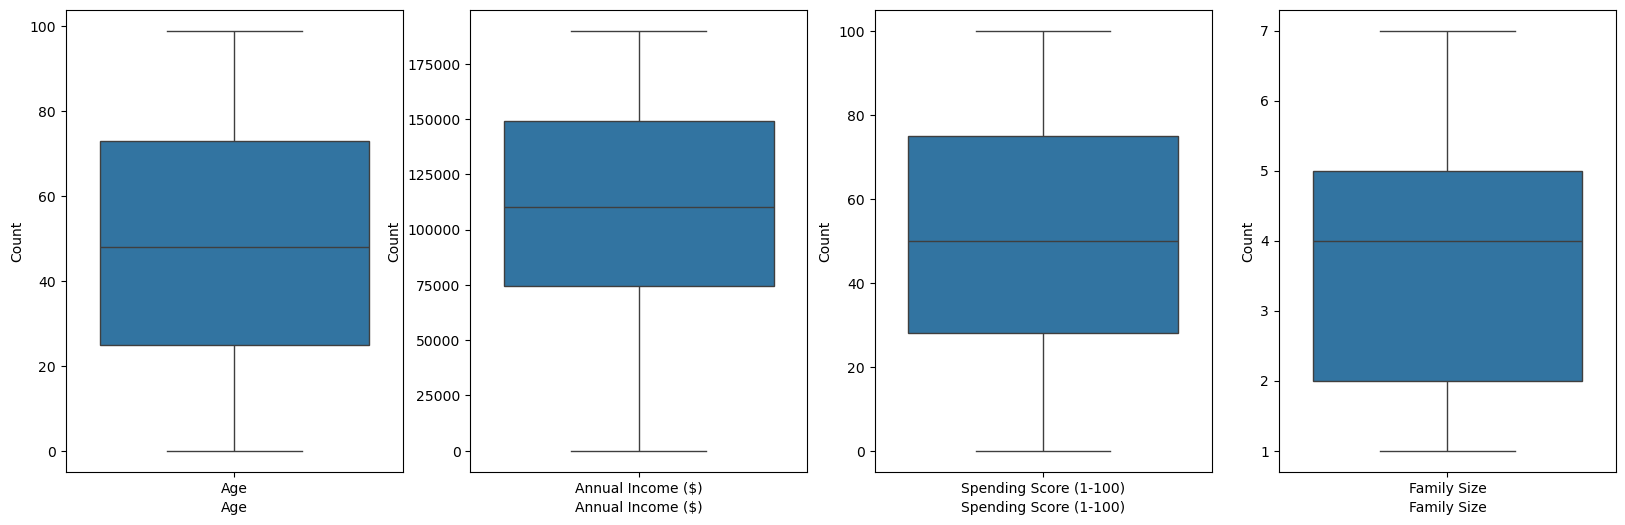

In [138]:
plt.figure(figsize=(20,6))
plt.subplot(1,4,1)
sns.boxplot(data=[df['Age']])
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1,4,2)
sns.boxplot(data=[df['Annual Income ($)']])
plt.xlabel('Annual Income ($)')
plt.ylabel('Count')

plt.subplot(1,4,3)
sns.boxplot(data=[df['Spending Score (1-100)']])
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')

plt.subplot(1,4,4)
sns.boxplot(data=[df['Family Size']])
plt.xlabel('Family Size')
plt.ylabel('Count')


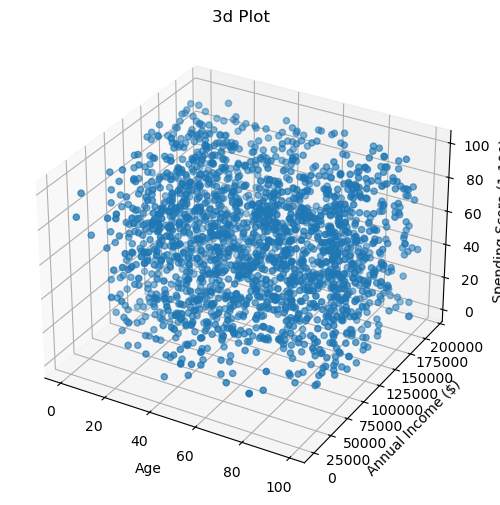

In [139]:
fig = plt.figure(figsize=(20, 6))

ax= fig.add_subplot(projection="3d")

scatter = ax.scatter(df['Age'],df['Annual Income ($)'], df['Spending Score (1-100)'])

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income ($)')
ax.set_zlabel('Spending Score (1-100)')


ax.set_title('3d Plot')

plt.show()

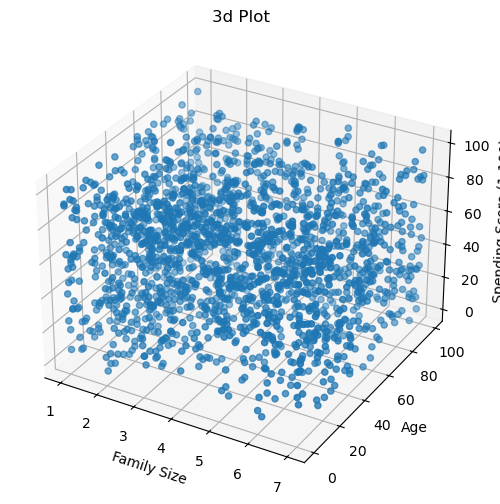

In [140]:
fig = plt.figure(figsize=(20, 6))

ax= fig.add_subplot(projection="3d")

scatter = ax.scatter(df['Family Size'],df['Age'], df['Spending Score (1-100)'])

ax.set_xlabel('Family Size')
ax.set_ylabel('Age')
ax.set_zlabel('Spending Score (1-100)')


ax.set_title('3d Plot')

plt.show()

In [141]:
scaler= StandardScaler()
scaled_features= scaler.fit_transform(df[['Age', 'Annual Income ($)', 'Spending Score (1-100)']])
scaled_df= pd.DataFrame(scaled_features, columns=['Age', 'Annual Income ($)', 'Spending Score (1-100)'])
scaled_df.head()

,Age,Annual Income ($),Spending Score (1-100)
0,-1.054089,-2.093501,-0.428339
1,-0.983723,-1.656133,1.075546
2,-1.018906,-0.540845,-1.609962
3,-0.913356,-1.131292,0.932319
4,-0.631891,-1.590528,-0.392532


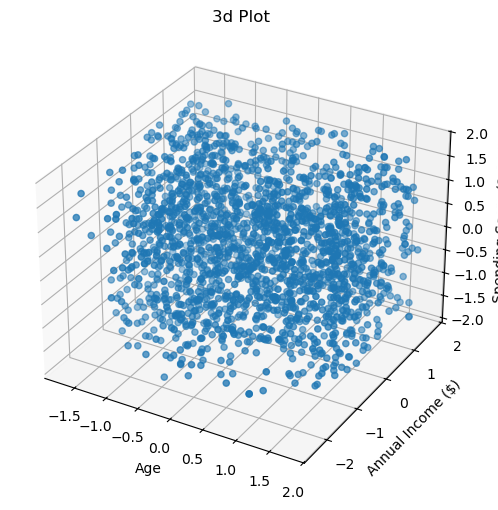

In [142]:
fig = plt.figure(figsize=(20, 6))

ax= fig.add_subplot(projection="3d")

scatter = ax.scatter(scaled_df['Age'],scaled_df['Annual Income ($)'], scaled_df['Spending Score (1-100)'])

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income ($)')
ax.set_zlabel('Spending Score (1-100)')


ax.set_title('3d Plot')

plt.show()